# Data Cleaning & EDA

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [81]:
data = pd.read_csv("../data/raw/Austin_Weather_99_23.csv")
data.shape

(10354, 10)

### Missing counts & other basic stuff

In [82]:
data.isnull().sum()  # missing counts for each column

Date                         0
TempHighF                    0
TempLowF                     0
TempAvgF                     0
DewPointAvgF                 4
HumidityAvgPercent           1
sealevelpressure             0
VisibilityAvgMiles           4
PrecipitationSumInches     204
Events                    6318
dtype: int64

In [83]:
data.head()

,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92,1008.7,4.2,NaN,NaN
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,NaN,NaN
2,1/3/1999,39.7,30.3,35.6,12.1,39,1029.8,9.9,NaN,NaN
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,NaN,NaN
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,NaN,NaN


In [84]:
data.describe()

,TempHighF,TempLowF,TempAvgF,PrecipitationSumInches
count,10354.000000,10354.000000,10354.000000,10150.000000
mean,80.349189,59.701111,69.491733,0.094914
std,14.771837,14.523552,14.077261,0.360494
min,22.600000,8.200000,15.700000,0.000000
25%,71.000000,48.000000,59.200000,0.000000
50%,82.300000,62.850000,71.900000,0.000000
75%,92.000000,72.900000,81.400000,0.006000
max,110.400000,84.500000,95.100000,7.489000


### Visualization

Text(0.5, 0, 'High (in Farenheit)')

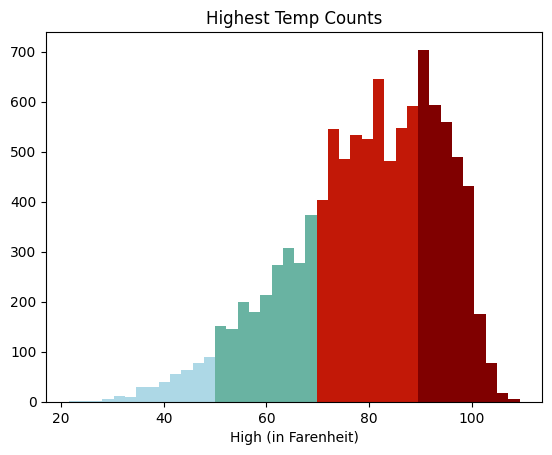

In [85]:
TempHighF, bin_edges = np.histogram(data["TempHighF"], bins=40)
cold = "lightblue"
med = "#69B3A2"
moderate = "#c21807"
extreme = "#800000"

colors = []

for bin_edge in bin_edges:
    if bin_edge < 50:
        colors.append(cold)
    elif bin_edge < 70:
        colors.append(med)
    elif bin_edge < 90:
        colors.append(moderate)
    else:
        colors.append(extreme)

plt.bar(
    bin_edges[:-1],
    TempHighF,
    width=np.diff(bin_edges),
    color=colors,
    edgecolor='none'
)

plt.title('Highest Temp Counts')
plt.xlabel('High (in Farenheit)')

### Data Cleaning

In [86]:
# Step 1: Convert Date to datetime
data['Date'] = pd.to_datetime(data['Date'])
print("\n✓ Date converted to datetime")

# Step 2: Handle Precipitation (missing = no rain)
missing_precip = data['PrecipitationSumInches'].isnull().sum()
data['PrecipitationSumInches'].fillna(0, inplace=True)
print(f"✓ Filled {missing_precip} missing precipitation values with 0")

# Step 3: Drop Events column (too many missing)
missing_events = data['Events'].isnull().sum()
print(f"✓ Dropping Events column ({missing_events} missing, {missing_events/len(data)*100:.1f}%)")
data.drop('Events', axis=1, inplace=True)

# Step 4: Interpolate small gaps
interpolate_cols = ['DewPointAvgF', 'HumidityAvgPercent', 'VisibilityAvgMiles']
for col in interpolate_cols:
    missing = data[col].isnull().sum()
    if missing > 0:
        data[col].interpolate(method='linear', inplace=True)
        data[col].fillna(method='ffill', inplace=True)
        data[col].fillna(method='bfill', inplace=True)
        print(f"✓ Interpolated {missing} missing values in {col}")

# Step 5: Sort by date
data.sort_values('Date', inplace=True)
data.reset_index(drop=True, inplace=True)
print("✓ Data sorted by date")

# Final check
remaining_missing = data.isnull().sum().sum()
print(f"\n✓ Data cleaning complete! Remaining missing values: {remaining_missing}")


✓ Date converted to datetime
✓ Filled 204 missing precipitation values with 0
✓ Dropping Events column (6318 missing, 61.0%)
✓ Interpolated 4 missing values in DewPointAvgF
✓ Interpolated 1 missing values in HumidityAvgPercent
✓ Interpolated 4 missing values in VisibilityAvgMiles
✓ Data sorted by date

✓ Data cleaning complete! Remaining missing values: 0


C:\Users\flori\AppData\Local\Temp\ipykernel_25208\608814139.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['PrecipitationSumInches'].fillna(0, inplace=True)
C:\Users\flori\AppData\Local\Temp\ipykernel_25208\608814139.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

### Date Processing & Deviation Calculations

In [87]:
# Date processing 

data['Date'] = pd.to_datetime(data['Date'])
data['Year'] = data['Date'].dt.year
data['DayOfYear'] = data['Date'].dt.dayofyear
data['WeekOfYear'] = data['Date'].dt.isocalendar().week

# Calculate Deviations
avg_temp_by_day = data.groupby('DayOfYear')['TempAvgF'].mean()
data['TempDeviation'] = data.apply(
    lambda row: row['TempAvgF'] - avg_temp_by_day[row['DayOfYear']],
    axis = 1
)

### Daily Heatmap

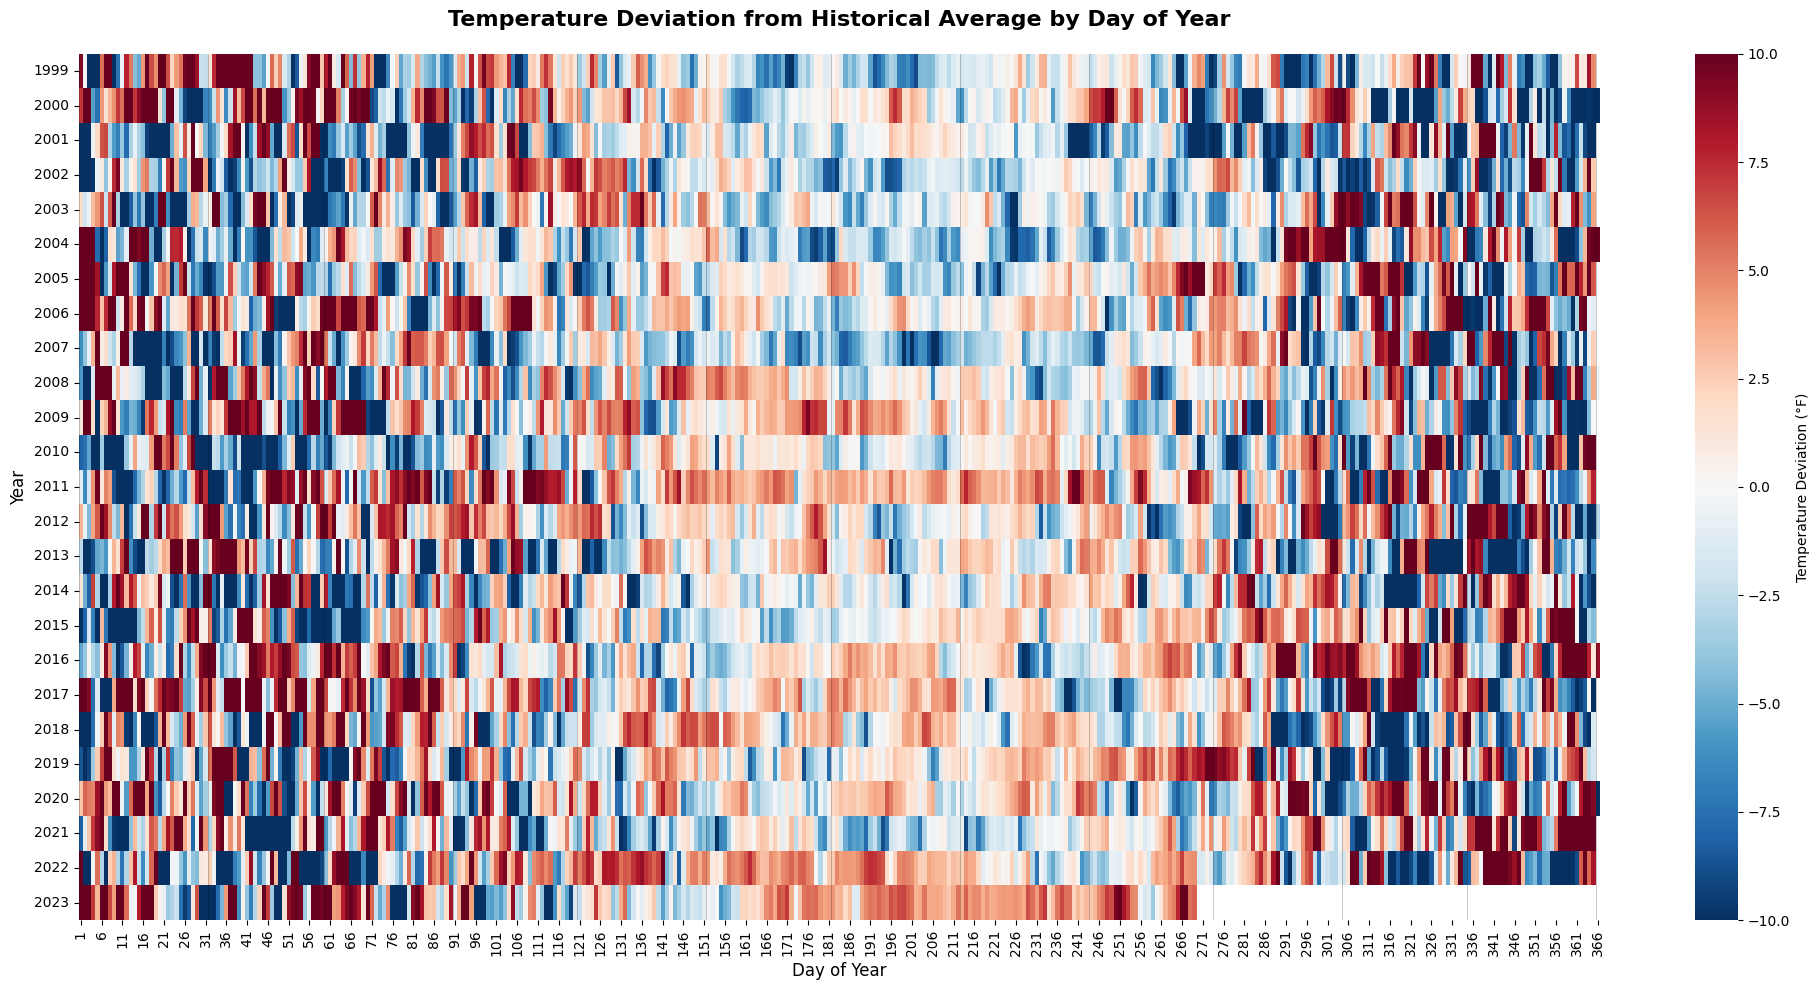

In [88]:
fig, ax = plt.subplots(figsize=(20, 10))

# Pivoting heatmap data: rows = year, columns = day of year
heatmap_data_daily = data.pivot_table(
    values = 'TempDeviation',
    index = 'Year',
    columns = 'DayOfYear',
    aggfunc = 'mean'
)

# Heatmap Creation
sns.heatmap(
    heatmap_data_daily,
    cmap = 'RdBu_r',
    center = 0,
    cbar_kws = {'label': 'Temperature Deviation (°F)'},
    ax = ax,
    vmin = -10,
    vmax = 10
)

ax.set_title('Temperature Deviation from Historical Average by Day of Year', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Day of Year', fontsize=12)
ax.set_ylabel('Year', fontsize=12)

month_boundaries = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
for boundary in month_boundaries:
    ax.axvline(x=boundary, color='black', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig('temp_deviation_heatmap_daily.png', dpi=300, bbox_inches='tight')
plt.show()

### Weekly Heatmap

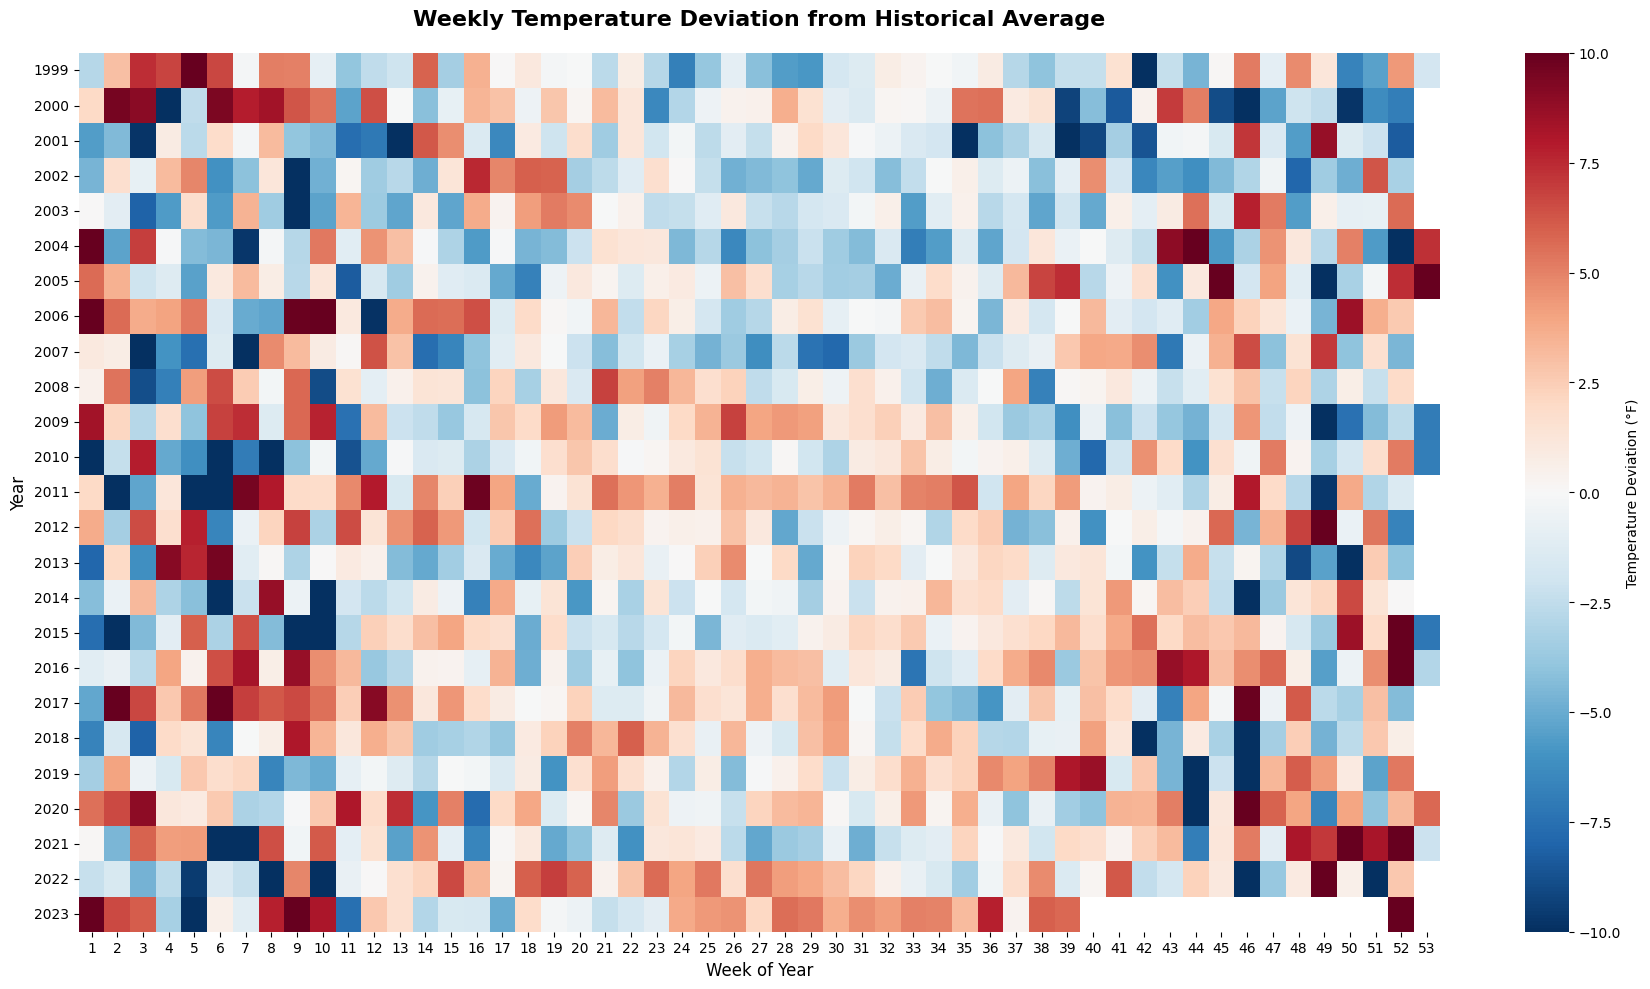

In [89]:
fig, ax = plt.subplots(figsize=(18, 10))

# Pivot data for weekly heatmap
heatmap_data_weekly = data.pivot_table(
    values='TempDeviation',
    index='Year',
    columns='WeekOfYear',
    aggfunc='mean'
)

# Create heatmap
sns.heatmap(
    heatmap_data_weekly,
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'Temperature Deviation (°F)'},
    ax=ax,
    vmin=-10,
    vmax=10
)

ax.set_title('Weekly Temperature Deviation from Historical Average', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Week of Year', fontsize=12)
ax.set_ylabel('Year', fontsize=12)

plt.tight_layout()
plt.savefig('temp_deviation_heatmap_weekly.png', dpi=300, bbox_inches='tight')
plt.show()

### Saving Cleaned Data

In [90]:
data.to_csv("../data/processed/Austin_Weather_Cleaned.csv", index=False)
print("✓ Cleaned data saved to '../data/processed/Austin_Weather_Cleaned.csv'")

✓ Cleaned data saved to '../data/processed/Austin_Weather_Cleaned.csv'
